In [193]:
from matplotlib import pyplot as plt
import gymnasium as gym
import numpy as np
import envs
from sklearn.neighbors import KernelDensity
from pathlib import Path

from learners import *
from analysis import *
from dist_run import *
from display_qtables import *

def get_tau(N): return (np.arange(N) + 0.5) / N

def get_kde(q, bandwidth):
    samples = q[:, None]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    return_kde = lambda x: np.exp(kde.score_samples(x[:, None]))
    return return_kde

In [194]:
params = Params(
    model_name="WindyRooms-v1",
    total_episodes=28_000,
    save_skip=10,
    n_runs=5,
    seed=123,
    
    lr_decay=4000,
    learning_rate=0.4,

    gamma=0.99,
    epsilon=0.1,
    huber_k=0.0,
    n_quantiles=32,
    
    action_size=None,
    state_size=None,
    map_size=None,
    learner_name=None,
)
rng = np.random.default_rng(params.seed)
tau = get_tau(params.n_quantiles)

env = gym.make(params.model_name, render_mode="rgb_array")
env.action_space.seed(params.seed)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
params = params._replace(map_size=env.unwrapped.shape)
s_init = env.unwrapped.start_state_index

save_to = "experiments/"+params.model_name.replace("-v1","")
Path(save_to).mkdir(parents=True, exist_ok=True)

In [195]:
policy, V = PolicyIteration(env, params.gamma)
returns = MonteCarlo(env, policy, params, s_init, rng, total_episodes=5_000)
explorer = EpsilonGreedy(params.epsilon, rng, policy=policy)
tau_returns = np.quantile(returns, tau)

100%|██████████| 5000/5000 [00:01<00:00, 2664.07it/s]


In [196]:
init_theta = np.full((params.state_size, params.action_size, params.n_quantiles), 0.0)

In [197]:
params_simple = params._replace(huber_k=0.0)
tables_run = run_env(env, QuantileRegression(params_simple, init_theta), explorer, params_simple)
a_max = tables_run.mean((0,-1))[-1,s_init].argmax()
q_simple = tables_run[:,:,s_init,a_max]

100%|██████████| 140000/140000 [06:02<00:00, 386.63it/s, ep=28000, run=5]


In [198]:
params_hub = params._replace(huber_k=1.0)
tables_run_hub = run_env(env, QuantileRegression(params_hub, init_theta), explorer, params_hub)
a_max_hub = tables_run_hub.mean((0,-1))[-1,s_init].argmax()
q_hub = tables_run_hub[:,:,s_init,a_max_hub]

100%|██████████| 140000/140000 [06:15<00:00, 372.87it/s, ep=28000, run=5]


In [212]:
display_qtables(tables_run_hub.mean((0,-1))[::20],params)

In [200]:
params_q = params._replace(n_quantiles=1)
tables_run_q = run_env(env, Qlearning(params_q), explorer, params_q)
a_max_q = tables_run_q.mean((0,-1))[-1,s_init].argmax()
q_q = tables_run_q[:,:,s_init,a_max_q]

100%|██████████| 140000/140000 [03:29<00:00, 669.39it/s, ep=28000, run=5]


In [201]:
best_simple = q_simple.mean(0)[-1]
best_hub = q_hub.mean(0)[-1]
best_q = q_q.mean(0)[-1]

In [202]:
W1 = lambda truth, estimate: abs(truth - estimate).mean(-1)
VSE = lambda z1, z2: (z1.mean(-1) - z2.mean(-1))**2

vd     = W1(tau_returns, q_simple)
vd_hub = W1(tau_returns, q_hub)

vf     = VSE(tau_returns, q_simple)
vf_hub = VSE(tau_returns, q_hub)
vf_q   = VSE(tau_returns, q_q)

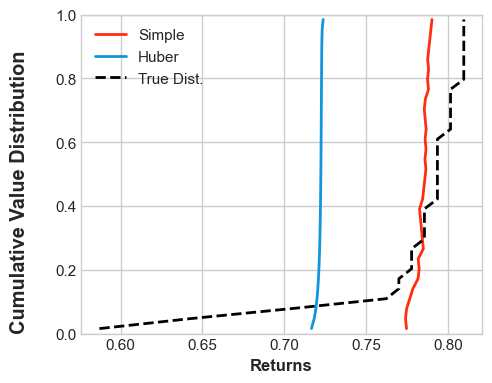

In [203]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Cumulative Value Distribution", fontweight="bold")

ax.plot(q_simple.mean(0)[-1], tau, label="Simple", linewidth=2, color="#FF2E0E")
ax.plot(q_hub.mean(0)[-1], tau, label="Huber", linewidth=2, color="#1394DE")
ax.plot(tau_returns, tau, label="True Dist.", linestyle="--", linewidth=2, color="black")

ax.set_ylim(0.0,1.0)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(f"{save_to}/cdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

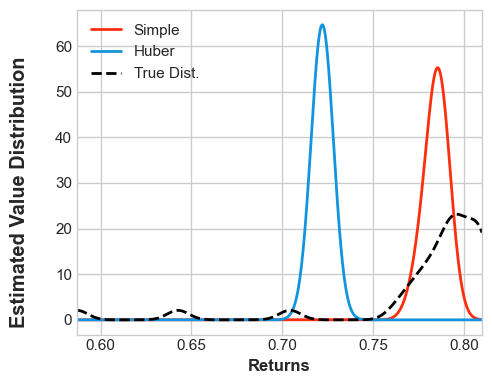

In [207]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Estimated Value Distribution", fontweight="bold")


lims = (np.min(np.array([best_simple, best_hub, tau_returns])), np.max(np.array([best_simple, best_hub, tau_returns])))
Xs = np.linspace(*lims, 10_000)
bw = 0.006

kde_simple = get_kde(q_simple.mean(0)[-1], bandwidth=bw)
ax.plot(Xs, kde_simple(Xs), label="Simple", linewidth=2, color="#FF2E0E")

kde_hub = get_kde(q_hub.mean(0)[-1], bandwidth=bw)
ax.plot(Xs, kde_hub(Xs), label="Huber", linewidth=2, color="#1394DE")

kde_ret = get_kde(tau_returns, bandwidth=bw)
ax.plot(Xs, kde_ret(Xs), label="True Dist.", linestyle="--", linewidth=2, color="black")

ax.set_xlim(*lims)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig(f"{save_to}/pdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

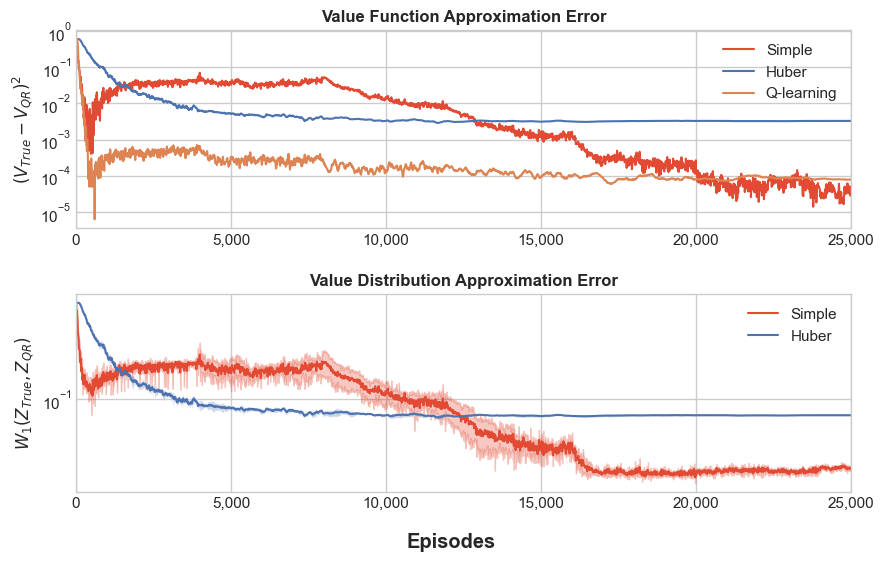

In [205]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10,6), gridspec_kw={'hspace': 0.33})
fig.supxlabel("Episodes", fontweight="bold")

# X = range(params.total_episodes//params.save_skip)
X = range(q_simple.shape[1])

axes[1].plot(vd.mean(0), label="Simple", color="#E24A33")
axes[1].plot(vd_hub.mean(0), label="Huber")
axes[1].fill_between(X, vd.mean(0) - vd.std(0), vd.mean(0) + vd.std(0), alpha=0.3, color="#E24A33")
axes[1].fill_between(X, vd_hub.mean(0) - vd_hub.std(0), vd_hub.mean(0) + vd_hub.std(0), alpha=0.3)

axes[1].set_title("Value Distribution Approximation Error", fontweight="bold")
axes[1].set_ylabel("$ W_1(Z_{True}, Z_{QR}) $")
axes[1].set_yscale("log")
ticks = axes[1].get_xticks().astype(int)
axes[1].set_xticks(ticks, [f"{x:,}" for x in ticks*params.save_skip])
axes[1].set_xlim(ticks[1], ticks[-2])
axes[1].legend(loc=1)


axes[0].plot(vf.mean(0), label="Simple", color="#E24A33")
axes[0].plot(vf_hub.mean(0), label="Huber")
axes[0].plot(vf_q.mean(0), label="Q-learning")

axes[0].set_title("Value Function Approximation Error", fontweight="bold")
axes[0].set_ylabel("$ (V_{True} - V_{QR} )^2 $")
axes[0].set_yscale("log")
axes[0].set_xticks(ticks, [f"{x:,}" for x in ticks*params.save_skip])
axes[0].set_xlim(ticks[1], ticks[-2])
axes[0].legend(loc=1)

plt.savefig(f"{save_to}/true_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()